# Лабораторная работа №3
# Деревья решений - Классификатор пола по голосу

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import tree
from sklearn import model_selection
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score

## Загрузка данных

In [3]:
voice_data = pd.read_csv('voice_gender.csv')
print("Первые 5 строк данных:")
print(voice_data.head())
print("\nИнформация о данных:")
print(voice_data.info())
print(f"\nКоличество пропусков: {voice_data.isnull().sum().sum()}")

# Разделение на признаки и целевую переменную
X = voice_data.drop('label', axis=1)
y = voice_data['label']

# Кодирование целевой переменной (для совместимости с sklearn)
y_encoded = y.map({'male': 1, 'female': 0})  # male=1, female=0

Первые 5 строк данных:
   meanfreq        sd    median       Q25       Q75       IQR       skew  \
0  0.059781  0.064241  0.032027  0.015071  0.090193  0.075122  12.863462   
1  0.066009  0.067310  0.040229  0.019414  0.092666  0.073252  22.423285   
2  0.077316  0.083829  0.036718  0.008701  0.131908  0.123207  30.757155   
3  0.151228  0.072111  0.158011  0.096582  0.207955  0.111374   1.232831   
4  0.135120  0.079146  0.124656  0.078720  0.206045  0.127325   1.101174   

          kurt    sp.ent       sfm  ...  centroid   meanfun    minfun  \
0   274.402905  0.893369  0.491918  ...  0.059781  0.084279  0.015702   
1   634.613855  0.892193  0.513724  ...  0.066009  0.107937  0.015826   
2  1024.927705  0.846389  0.478905  ...  0.077316  0.098706  0.015656   
3     4.177296  0.963322  0.727232  ...  0.151228  0.088965  0.017798   
4     4.333713  0.971955  0.783568  ...  0.135120  0.106398  0.016931   

     maxfun   meandom    mindom    maxdom   dfrange   modindx  label  
0  0.27586

## Задание 1: Решающие пни (глубина 1)

ЗАДАНИЕ 1: Решающие пни
Размер обучающей выборки: (2534, 20)
Размер тестовой выборки: (634, 20)


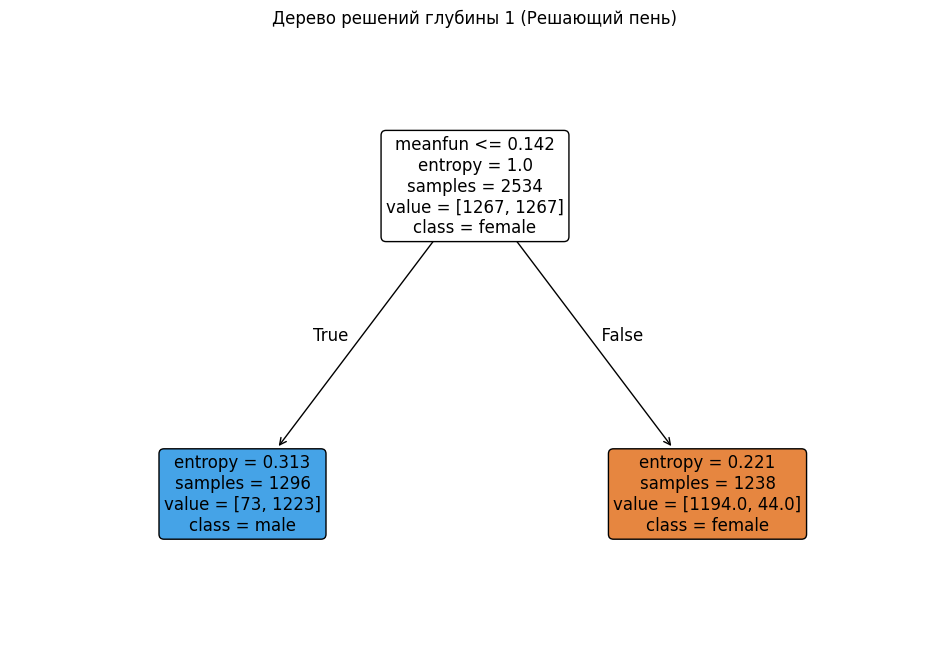


1. Признак в корневой вершине: meanfun
2. Оптимальное пороговое значение: 0.142
3. Процент наблюдений, для которых выполняется условие: 51.1%
4. Accuracy на тестовой выборке: 0.956


In [4]:
print("ЗАДАНИЕ 1: Решающие пни")

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)
print(f'Размер обучающей выборки: {X_train.shape}')
print(f'Размер тестовой выборки: {X_test.shape}')

# Создание и обучение дерева глубины 1
dt_stump = DecisionTreeClassifier(max_depth=1, criterion='entropy', random_state=42)
dt_stump.fit(X_train, y_train)

# Визуализация дерева
plt.figure(figsize=(12, 8))
tree.plot_tree(dt_stump, feature_names=X.columns, class_names=['female', 'male'],
               filled=True, rounded=True, fontsize=12)
plt.title("Дерево решений глубины 1 (Решающий пень)")
plt.savefig('decision_stump.png', dpi=300, bbox_inches='tight')
plt.show()

# 1. Определение признака в корневой вершине
feature_used = X.columns[dt_stump.tree_.feature[0]]
print(f"\n1. Признак в корневой вершине: {feature_used}")

# 2. Оптимальное пороговое значение
threshold = dt_stump.tree_.threshold[0]
print(f"2. Оптимальное пороговое значение: {threshold:.3f}")

# 3. Процент наблюдений, для которых выполняется условие
# Получаем количество объектов, попавших в левый дочерний узел
n_left = np.sum(X_train[feature_used] <= threshold)
n_total = len(X_train)
percent_left = (n_left / n_total) * 100
print(f"3. Процент наблюдений, для которых выполняется условие: {percent_left:.1f}%")

# 4. Предсказание и accuracy на тестовой выборке
y_pred_stump = dt_stump.predict(X_test)
accuracy_stump = accuracy_score(y_test, y_pred_stump)
print(f"4. Accuracy на тестовой выборке: {accuracy_stump:.3f}")

## Задание 2: Глубина 2

ЗАДАНИЕ 2: Дерево глубины 2


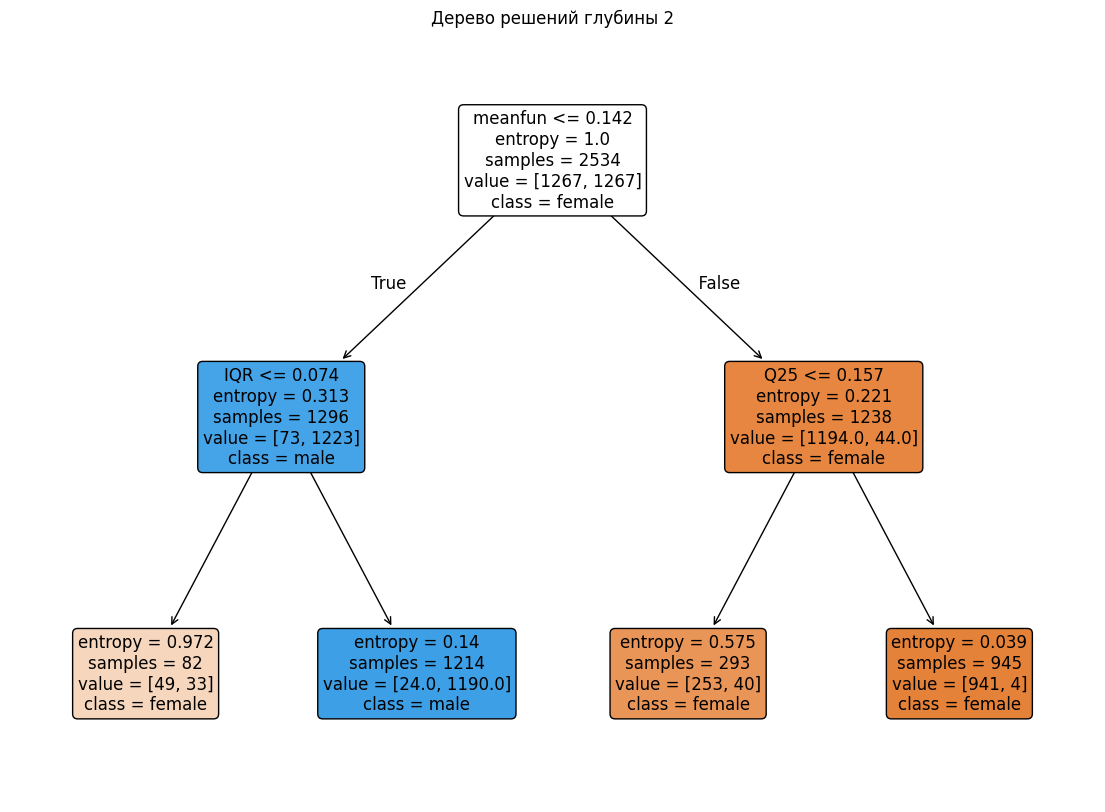


1. Признаки, используемые в дереве: {'meanfun', 'Q25', 'IQR'}
2. Количество листьев с классом female: 3
3. Accuracy на тестовой выборке: 0.962


In [5]:
print("ЗАДАНИЕ 2: Дерево глубины 2")

# Создание и обучение дерева глубины 2
dt_depth2 = DecisionTreeClassifier(max_depth=2, criterion='entropy', random_state=42)
dt_depth2.fit(X_train, y_train)

# Визуализация дерева
plt.figure(figsize=(14, 10))
tree.plot_tree(dt_depth2, feature_names=X.columns, class_names=['female', 'male'],
               filled=True, rounded=True, fontsize=12)
plt.title("Дерево решений глубины 2")
plt.savefig('decision_tree_depth2.png', dpi=300, bbox_inches='tight')
plt.show()

# 1. Определение используемых признаков
used_features = set()
for node in range(dt_depth2.tree_.node_count):
    if dt_depth2.tree_.feature[node] != -2:  # не лист
        used_features.add(X.columns[dt_depth2.tree_.feature[node]])
print(f"\n1. Признаки, используемые в дереве: {used_features}")

# 2. Количество листьев с классом female
leaf_indices = dt_depth2.tree_.children_left == -1  # листья
leaf_values = dt_depth2.tree_.value[leaf_indices]
female_leaves = np.sum([val[0][0] > val[0][1] for val in leaf_values])  # female = 0
print(f"2. Количество листьев с классом female: {female_leaves}")

# 3. Предсказание и accuracy на тестовой выборке
y_pred_depth2 = dt_depth2.predict(X_test)
accuracy_depth2 = accuracy_score(y_test, y_pred_depth2)
print(f"3. Accuracy на тестовой выборке: {accuracy_depth2:.3f}")

## Задание 3: Без ограничения глубины

ЗАДАНИЕ 3: Дерево без ограничения глубины

1. Глубина дерева: 12
2. Количество листьев: 54
3. Accuracy на обучающей выборке: 1.000
   Accuracy на тестовой выборке: 0.973


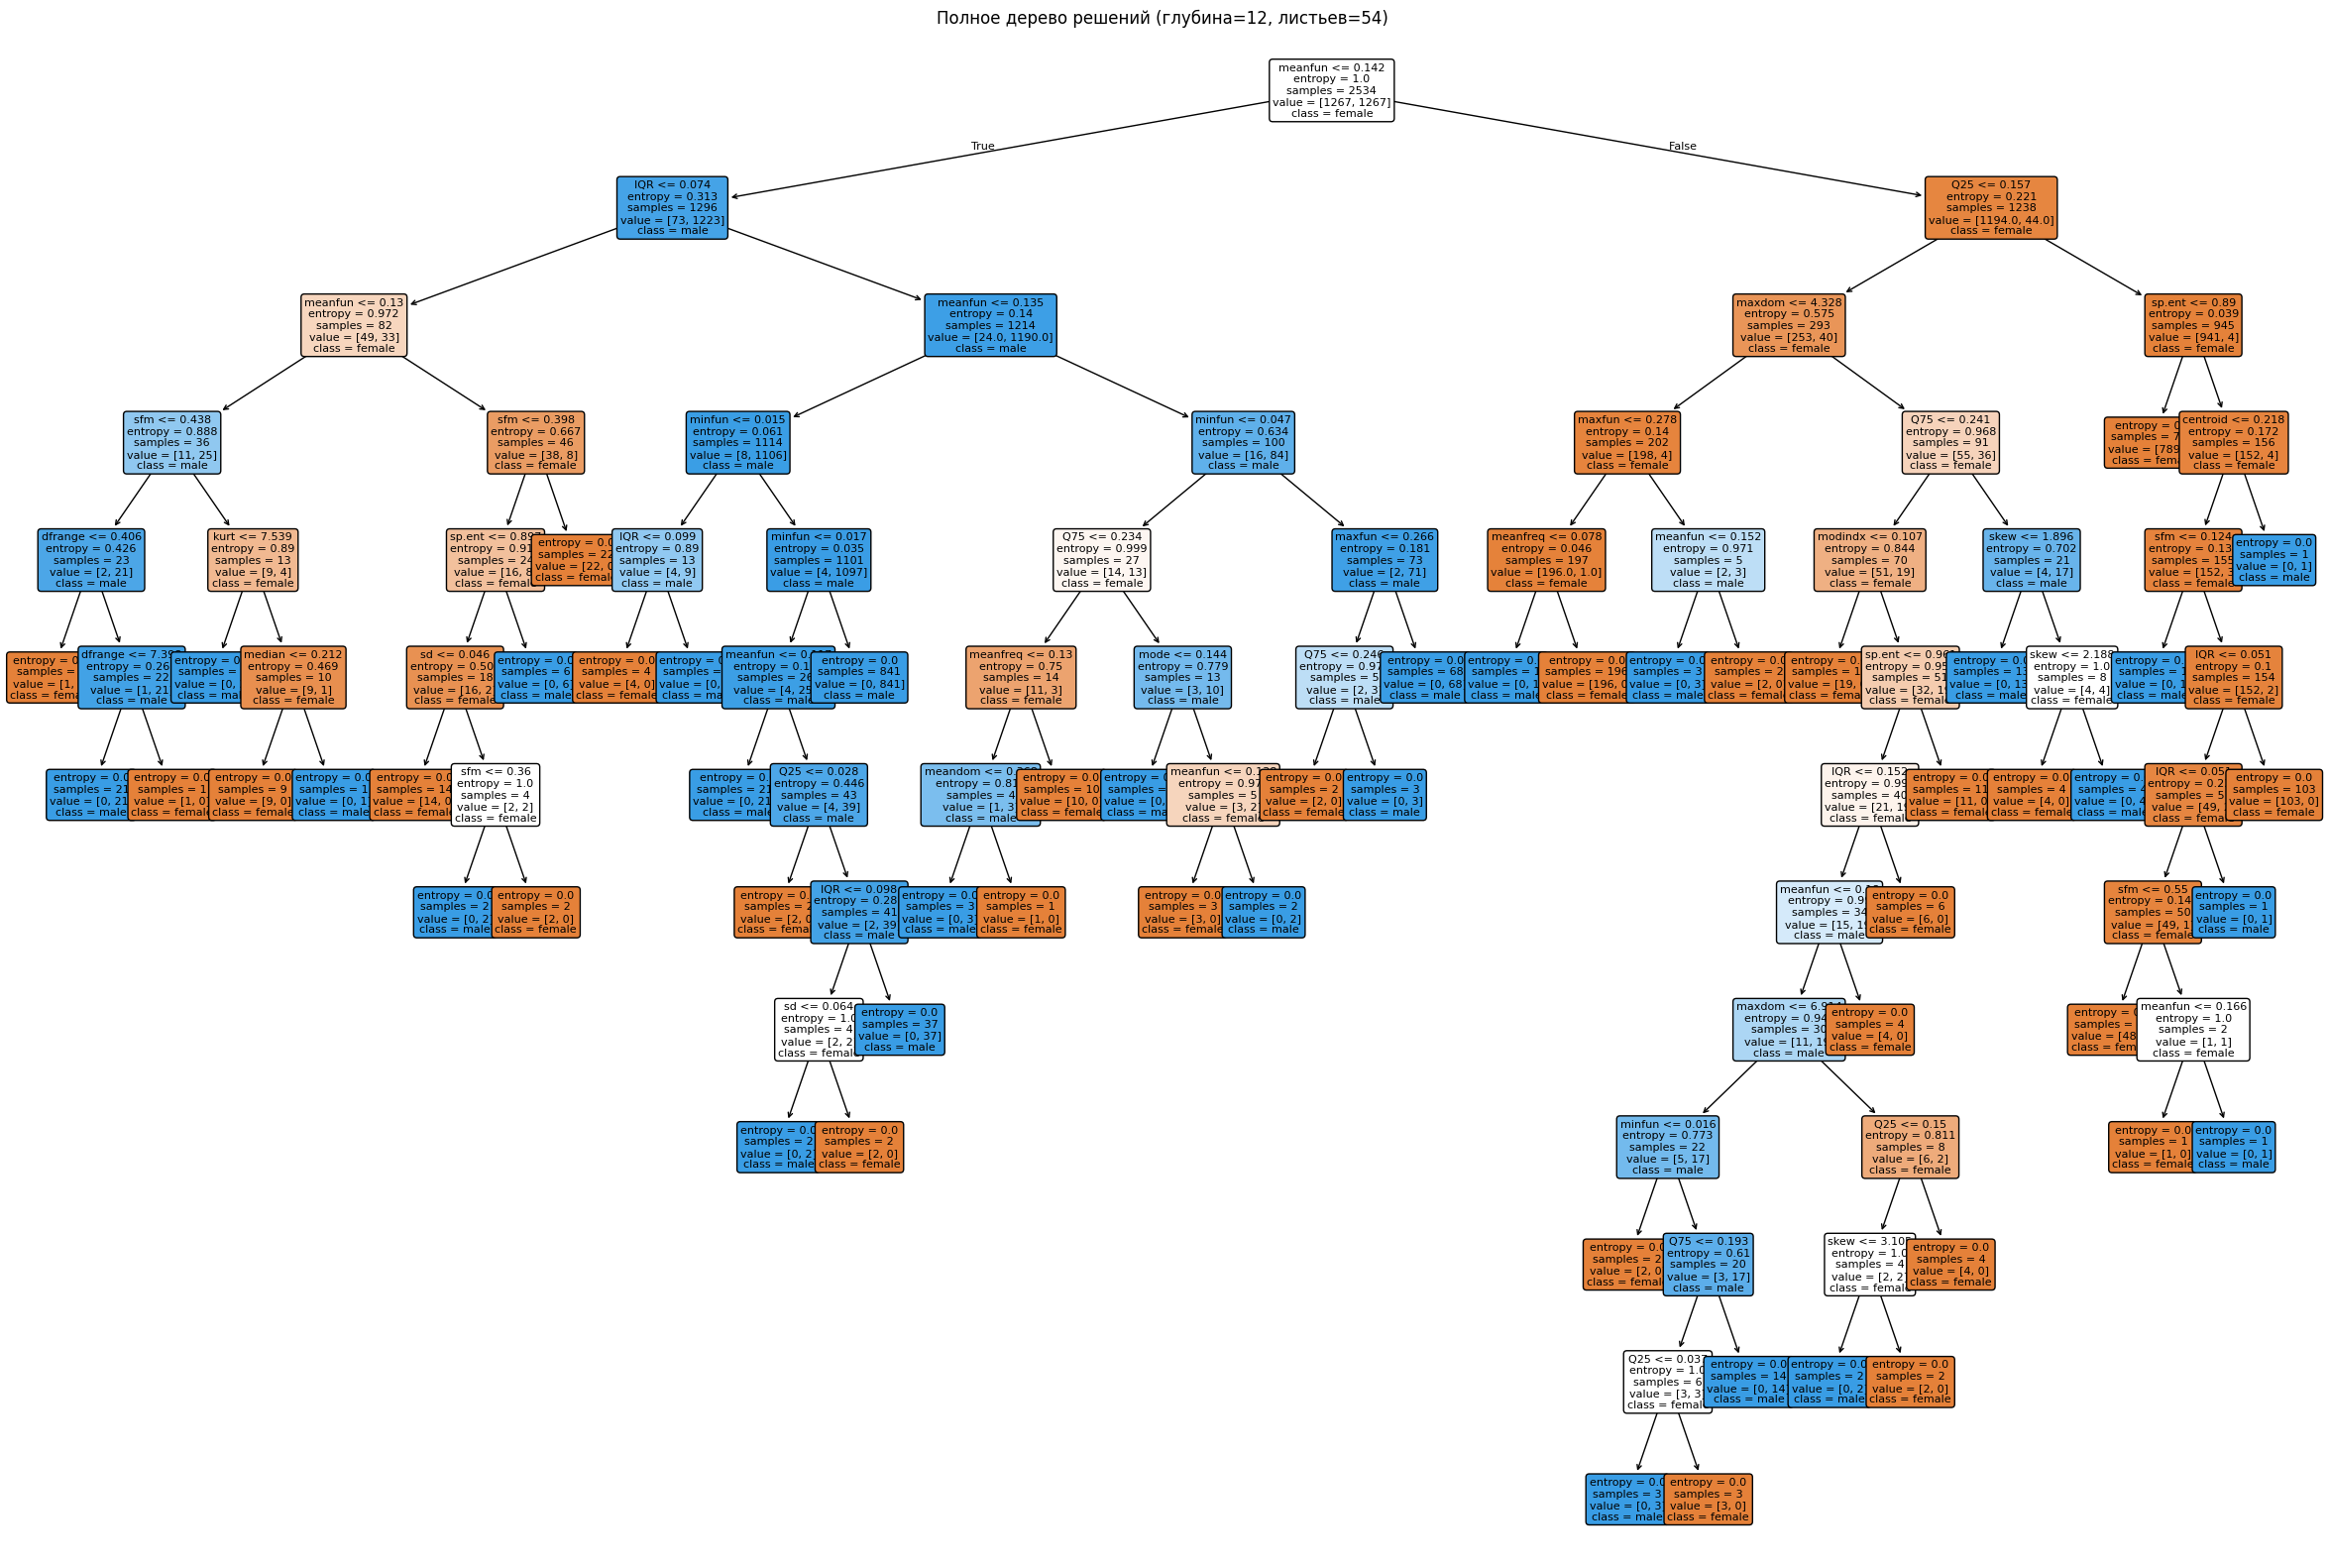

In [6]:
print("ЗАДАНИЕ 3: Дерево без ограничения глубины")

# Создание и обучение дерева без ограничения глубины
dt_full = DecisionTreeClassifier(criterion='entropy', random_state=0)
dt_full.fit(X_train, y_train)

# 1. Глубина дерева
depth_full = dt_full.get_depth()
print(f"\n1. Глубина дерева: {depth_full}")

# 2. Количество листьев
leaves_full = dt_full.get_n_leaves()
print(f"2. Количество листьев: {leaves_full}")

# 3. Accuracy на обучающей и тестовой выборках
y_train_pred_full = dt_full.predict(X_train)
y_test_pred_full = dt_full.predict(X_test)
accuracy_train_full = accuracy_score(y_train, y_train_pred_full)
accuracy_test_full = accuracy_score(y_test, y_test_pred_full)
print(f"3. Accuracy на обучающей выборке: {accuracy_train_full:.3f}")
print(f"   Accuracy на тестовой выборке: {accuracy_test_full:.3f}")

# Визуализация дерева (может быть большим, поэтому увеличим размер)
plt.figure(figsize=(30, 20))
tree.plot_tree(dt_full, feature_names=X.columns, class_names=['female', 'male'],
               filled=True, rounded=True, fontsize=8)
plt.title(f"Полное дерево решений (глубина={depth_full}, листьев={leaves_full})")
plt.savefig('full_decision_tree.png', dpi=300, bbox_inches='tight')
plt.show()

## Задание 4: GridSearchCV

ЗАДАНИЕ 4: Подбор гиперпараметров с GridSearchCV
Fitting 5 folds for each of 56 candidates, totalling 280 fits

Лучшие параметры: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 4}
1. Лучший критерий информативности: Критерий Джини
2. Оптимальная максимальная глубина: 5
3. Оптимальное минимальное количество объектов для разбиения: 4
4. Accuracy на обучающей выборке: 0.987
   Accuracy на тестовой выборке: 0.975


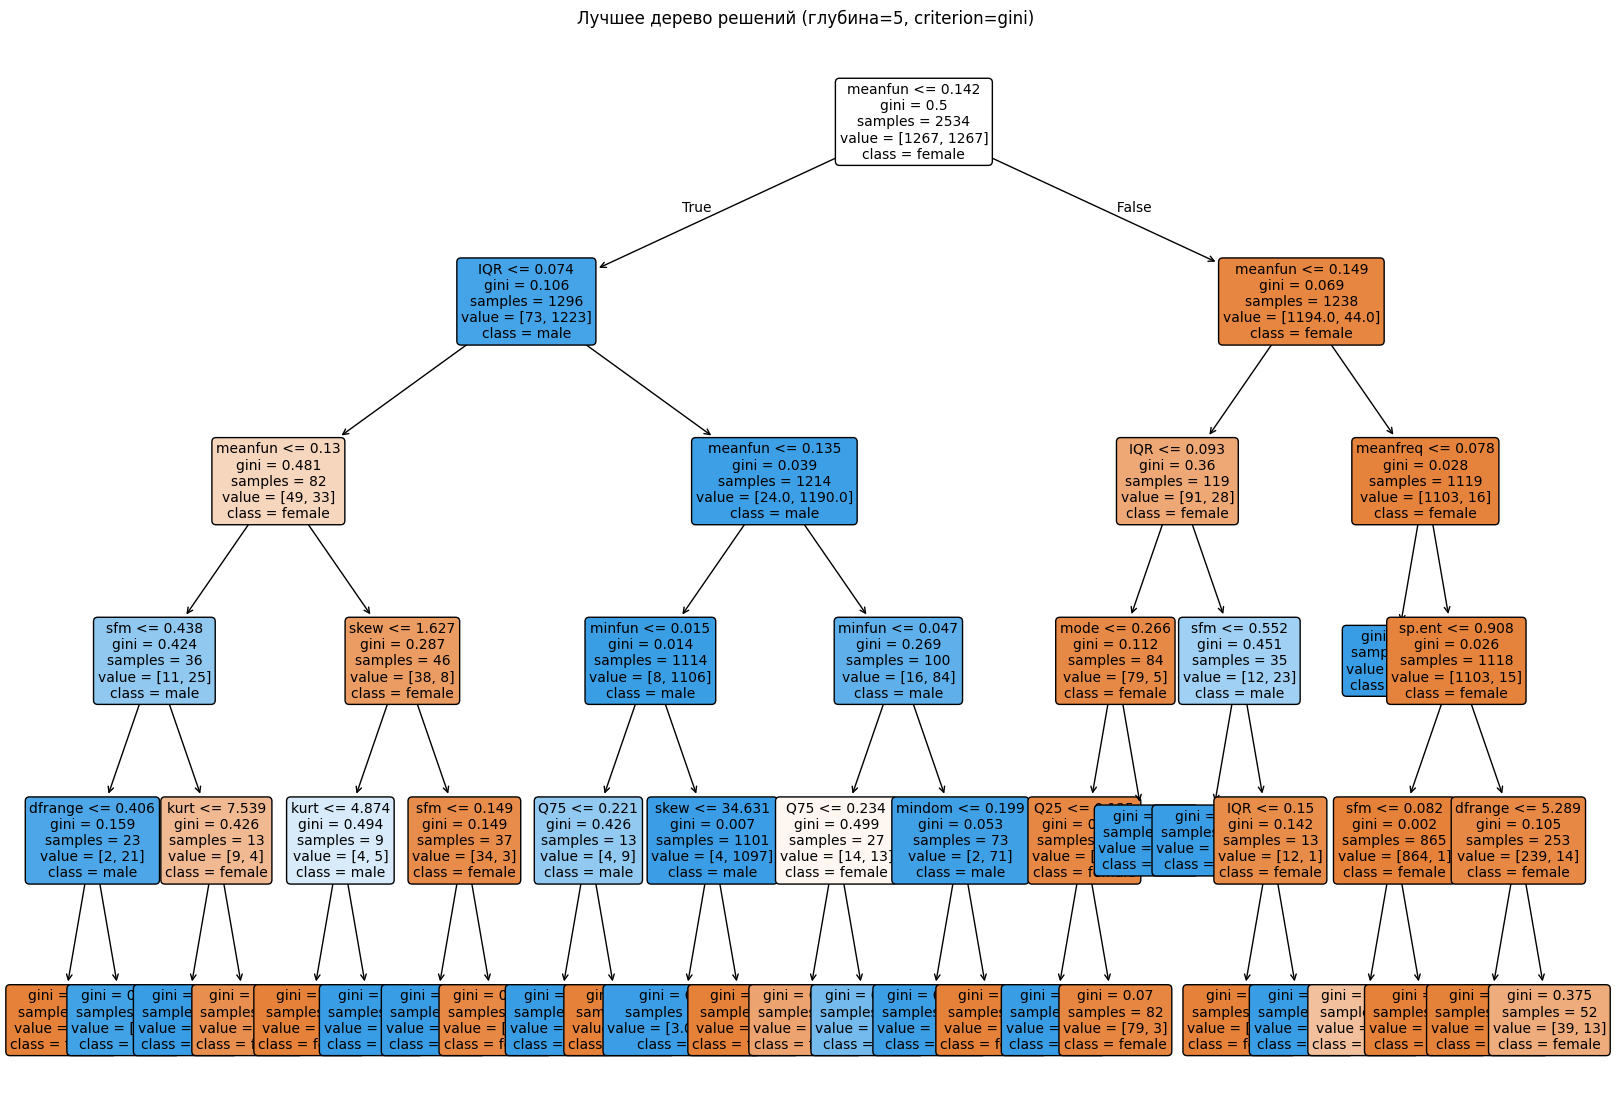


ЗАДАНИЕ 5: Важность признаков

Важность признаков:
     Feature  Importance
12   meanfun    0.881729
5        IQR    0.058321
9        sfm    0.018467
13    minfun    0.009792
4        Q75    0.007985
7       kurt    0.006743
18   dfrange    0.005524
6       skew    0.004323
0   meanfreq    0.001603
16    mindom    0.001581
3        Q25    0.001511
10      mode    0.001475
8     sp.ent    0.000947
1         sd    0.000000
2     median    0.000000
11  centroid    0.000000
15   meandom    0.000000
14    maxfun    0.000000
17    maxdom    0.000000
19   modindx    0.000000


/tmp/ipykernel_4218/1246825781.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


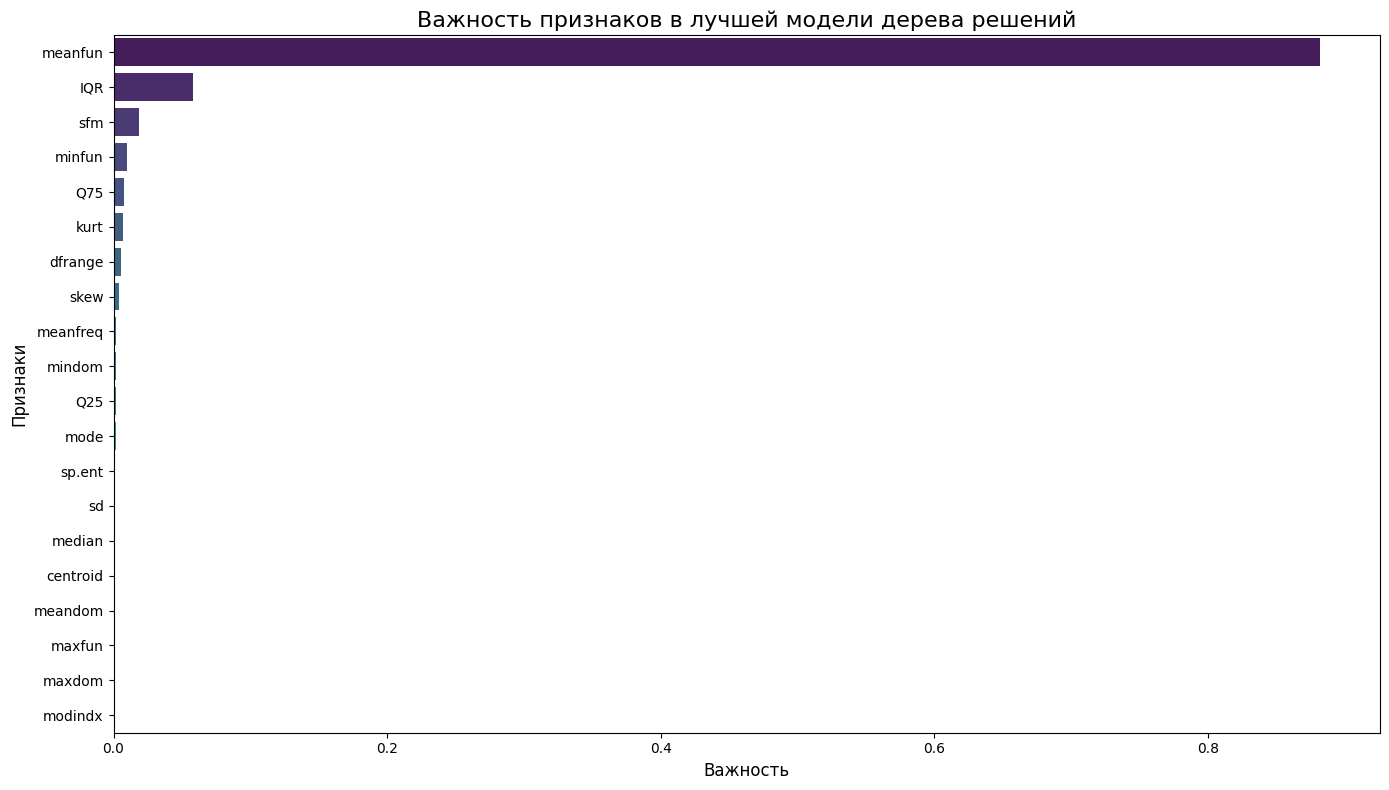


Топ-3 наиболее важных признака:
1. meanfun
2. IQR
3. sfm

Буквенные обозначения топ-3 признаков:
D: meanfun
C: IQR
F: sfm


In [7]:
print("ЗАДАНИЕ 4: Подбор гиперпараметров с GridSearchCV")

# Параметры для поиска
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [4, 5, 6, 7, 8, 9, 10],
    'min_samples_split': [3, 4, 5, 10]
}

# Кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=0),
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

# Лучшие параметры
print(f"\nЛучшие параметры: {grid_search.best_params_}")

# 1. Лучший критерий
best_criterion = grid_search.best_params_['criterion']
print(f"1. Лучший критерий информативности: {'Критерий Джини' if best_criterion == 'gini' else 'Энтропия Шеннона'}")

# 2. Оптимальная максимальная глубина
best_depth = grid_search.best_params_['max_depth']
print(f"2. Оптимальная максимальная глубина: {best_depth}")

# 3. Оптимальное минимальное количество объектов
best_min_samples_split = grid_search.best_params_['min_samples_split']
print(f"3. Оптимальное минимальное количество объектов для разбиения: {best_min_samples_split}")

# Лучшая модель
best_dt = grid_search.best_estimator_

# 4. Accuracy на обучающей и тестовой выборках
y_train_pred_best = best_dt.predict(X_train)
y_test_pred_best = best_dt.predict(X_test)
accuracy_train_best = accuracy_score(y_train, y_train_pred_best)
accuracy_test_best = accuracy_score(y_test, y_test_pred_best)
print(f"4. Accuracy на обучающей выборке: {accuracy_train_best:.3f}")
print(f"   Accuracy на тестовой выборке: {accuracy_test_best:.3f}")

# Визуализация лучшего дерева
plt.figure(figsize=(20, 14))
tree.plot_tree(best_dt, feature_names=X.columns, class_names=['female', 'male'],
               filled=True, rounded=True, fontsize=10)
plt.title(f"Лучшее дерево решений (глубина={best_depth}, criterion={best_criterion})")
plt.savefig('best_decision_tree.png', dpi=300, bbox_inches='tight')
plt.show()

# %% Задание 5: Важность признаков
print("\n" + "="*50)
print("ЗАДАНИЕ 5: Важность признаков")
print("="*50)

# Важность признаков
feature_importances = best_dt.feature_importances_
feature_names = X.columns

# Создание DataFrame с важностью
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("\nВажность признаков:")
print(importance_df)

# Визуализация в виде столбчатой диаграммы
plt.figure(figsize=(14, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Важность признаков в лучшей модели дерева решений', fontsize=16)
plt.xlabel('Важность', fontsize=12)
plt.ylabel('Признаки', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Топ-3 наиболее важных признака
top3_features = importance_df.head(3)['Feature'].tolist()
print(f"\nТоп-3 наиболее важных признака:")
for i, feat in enumerate(top3_features, 1):
    print(f"{i}. {feat}")

# Соответствие буквам из задания
feature_mapping = {
    'meanfreq': 'A',
    'median': 'B',
    'IQR': 'C',
    'meanfun': 'D',
    'minfun': 'E',
    'Q25': 'F',
    'sfm': 'F'
}
print("\nБуквенные обозначения топ-3 признаков:")
for feat in top3_features:
    letter = feature_mapping.get(feat, '?')
    print(f"{letter}: {feat}")

## Сохранение результатов в файл

In [8]:
print("РЕЗУЛЬТАТЫ ВСЕХ ЗАДАНИЙ")

results = {
    'Задание 1': {
        'Корневой признак': feature_used,
        'Пороговое значение': f'{threshold:.3f}',
        'Процент в левом узле': f'{percent_left:.1f}%',
        'Accuracy тест': f'{accuracy_stump:.3f}'
    },
    'Задание 2': {
        'Используемые признаки': ', '.join(used_features),
        'Листьев с классом female': female_leaves,
        'Accuracy тест': f'{accuracy_depth2:.3f}'
    },
    'Задание 3': {
        'Глубина': depth_full,
        'Количество листьев': leaves_full,
        'Accuracy обучение': f'{accuracy_train_full:.3f}',
        'Accuracy тест': f'{accuracy_test_full:.3f}'
    },
    'Задание 4': {
        'Критерий': best_criterion,
        'Максимальная глубина': best_depth,
        'min_samples_split': best_min_samples_split,
        'Accuracy обучение': f'{accuracy_train_best:.3f}',
        'Accuracy тест': f'{accuracy_test_best:.3f}'
    },
    'Задание 5': {
        'Топ-1 признак': importance_df.iloc[0]['Feature'],
        'Топ-2 признак': importance_df.iloc[1]['Feature'],
        'Топ-3 признак': importance_df.iloc[2]['Feature']
    }
}

for task, values in results.items():
    print(f"\n{task}:")
    for key, val in values.items():
        print(f"  {key}: {val}")

РЕЗУЛЬТАТЫ ВСЕХ ЗАДАНИЙ

Задание 1:
  Корневой признак: meanfun
  Пороговое значение: 0.142
  Процент в левом узле: 51.1%
  Accuracy тест: 0.956

Задание 2:
  Используемые признаки: meanfun, Q25, IQR
  Листьев с классом female: 3
  Accuracy тест: 0.962

Задание 3:
  Глубина: 12
  Количество листьев: 54
  Accuracy обучение: 1.000
  Accuracy тест: 0.973

Задание 4:
  Критерий: gini
  Максимальная глубина: 5
  min_samples_split: 4
  Accuracy обучение: 0.987
  Accuracy тест: 0.975

Задание 5:
  Топ-1 признак: meanfun
  Топ-2 признак: IQR
  Топ-3 признак: sfm
